## Data Set : NationalNames.csv 
download : https://drive.google.com/file/d/0B9fcvsgEhJNsN0FUaGZudFYyTVU/view

-  Id: 행 구분자 

-  Name: 유아 이름

-  Year: 출생연도

-  Gender: 성별

-  Count: 해당 (이름, 연도, 성별)의 출생횟수

### 문제 1) NationalNames.csv 파일을 읽어오고, 컬럼을 'id', 'name', 'year', 'sex', 'births' 로 바꾸기 
- dataframe으로 읽어올 것
- 'names' 변수에 저장할 것

In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('./data/NationalNames.csv')
df.columns = ['id', 'name', 'year', 'sex', 'births']
df

,id,name,year,sex,births
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746
...,...,...,...,...,...
1825428,1825429,Zykeem,2014,M,5
1825429,1825430,Zymeer,2014,M,5
1825430,1825431,Zymiere,2014,M,5
1825431,1825432,Zyran,2014,M,5


### 문제 2) 2012년 이후에 태어난  'Emma' 이름을 가진 남자 아이에 대한 총 출생횟수 구하기 

In [10]:
total_birth = df.loc[(df['year'] > 2012) & (df['name'] == 'Emma') & (df['sex'] == 'M'), :]
total_birth
total_birth_count = total_birth['births'].sum()
total_birth_count

np.int64(30)

### 문제 3) 각 연도별 남아와 여아의 총 출생횟수를 산출하고, 라인 플롯으로 나타내기 
- index : 연도
- 출력 컬럼 : 여아, 남아
- value :각 연도별 여아 총 출생횟수, 남아 총 출생횟수
- 라인플롯의 제목 : 'The graph showing changes for births per year' 

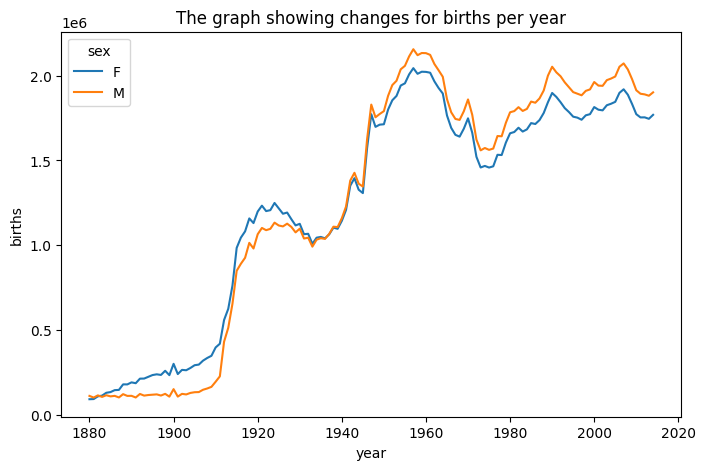

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

year_df = df.groupby(['year', 'sex'])['births'].sum().reset_index()
year_df

plt.figure(figsize=(8,5))
sns.lineplot(data = year_df, x='year', y='births', hue='sex')
plt.title('The graph showing changes for births per year')
plt.show()

### 문제 4) 각 연도, 성별 그룹 내에서 각 이름의 출생횟수가 각 그룹에서 차지하는 비중(%)을 나타내는 열 추가하기  
 - 추가 열이름 : 'pct'로 생성 
 - 'pct'열에 각 연도, 성별 그룹내의 각 이름에 대한 출생횟수 비중을 계산하여 추가

In [45]:
birth_df = df.groupby(['year', 'sex'])['births'].sum().reset_index()
birth_df['pct'] = np.nan
birth_df

total_birth = birth_df.groupby('year')['births'].sum().reset_index()

for row in birth_df.to_dict('records'):
  total = total_birth.loc[total_birth['year'] == row['year'], 'births'].iloc[0]
  pct = round((row['births'] / total) * 100, 2)
  birth_df.loc[(birth_df['year'] == row['year']) & (birth_df['sex'] == row['sex']), 'pct'] = pct 

birth_df


,year,sex,births,pct
0,1880,F,90993,45.16
1,1880,M,110491,54.84
2,1881,F,91954,47.72
3,1881,M,100745,52.28
4,1882,F,107850,48.68
...,...,...,...,...
265,2012,M,1889414,51.86
266,2013,F,1745339,48.12
267,2013,M,1881463,51.88
268,2014,F,1768775,48.19


## 5. 각 연도별, 성별에 따른 출생 빈도수가 가장 높은 이름 100개 추출하기

In [55]:
year_unique = df['year'].unique()
year_unique

new_df = pd.DataFrame(columns=['year', 'sex', 'name', 'births'])

for year in year_unique:
  temp_df = df.loc[df['year'] == year, :]
  man_df = temp_df.loc[temp_df['sex'] == 'M', :]
  woman_df = temp_df.loc[temp_df['sex'] == 'F', :]
  man_df.sort_values('births', ascending=False, inplace=True)
  woman_df.sort_values('births', ascending=False, inplace=True)

  new_df = pd.concat(
    [new_df, man_df.head(100), woman_df.head(100)],
    ignore_index=True
  )

new_df = new_df.drop(columns='id')
new_df

/tmp/ipykernel_98787/3706540414.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  man_df.sort_values('births', ascending=False, inplace=True)
/tmp/ipykernel_98787/3706540414.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  woman_df.sort_values('births', ascending=False, inplace=True)
/tmp/ipykernel_98787/3706540414.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  man_df.sort_values('births', ascending=False, inplace=True)
/t

,year,sex,name,births
0,1880,M,John,9655
1,1880,M,William,9532
2,1880,M,James,5927
3,1880,M,Charles,5348
4,1880,M,George,5126
...,...,...,...,...
26995,2014,F,Isabelle,3044
26996,2014,F,Alice,3042
26997,2014,F,Vivian,3040
26998,2014,F,Hadley,2992


## 6. 남자아이 / 여자아이 이름에 대한 시대별 추이 구하기 
 -  전체연도에서 성별구분없이 가장 많이 출생한 이름 top10을 구해서 
    top10에 해당하는 이름에 대한 출생횟수 변화추이를 각각 이름별로 
    subplot 10행 1열의 라인플롯으로 나타낸다
      
 - 그래프를 기반으로 결과 도출 (2000년을 기준으로 전에는 어떤 이름들이 
   유행했고, 이후에는 어떤 이름들이 유행했는지 확인)
   
 - 하기 subplot과 같은 방식으로 그래프 생성하기 

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('./data/NationalNames.csv')
df
df.columns = ['id', 'name', 'year', 'sex', 'births']
top_name_df = df.groupby('name')['births'].sum().reset_index().head(10)
top_name_df
top_names = top_name_df['name'].to_list()
top_names

['Aaban',
 'Aabha',
 'Aabid',
 'Aabriella',
 'Aadam',
 'Aadan',
 'Aadarsh',
 'Aaden',
 'Aadesh',
 'Aadhav']

In [3]:
final_df = pd.DataFrame(columns=['year','name','births','sex'])
for name in top_names:
  # 전체 데이터에서 맞는 이름의 데이터만 불러와 df 만들기
  temp_df = df.loc[df['name'] == name, :]
  # 그룹을 짓고 해당연도의 출생횟수 합 구하기
  total_temp_df = temp_df.groupby(['year','name','sex'])['births'].sum().reset_index()
  final_df = pd.concat([final_df, total_temp_df], ignore_index=True)

final_df


,year,name,births,sex
0,2007,Aaban,5,M
1,2009,Aaban,6,M
2,2010,Aaban,9,M
3,2011,Aaban,11,M
4,2012,Aaban,11,M
...,...,...,...,...
80,2010,Aadhav,13,M
81,2011,Aadhav,6,M
82,2012,Aadhav,18,M
83,2013,Aadhav,24,M


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

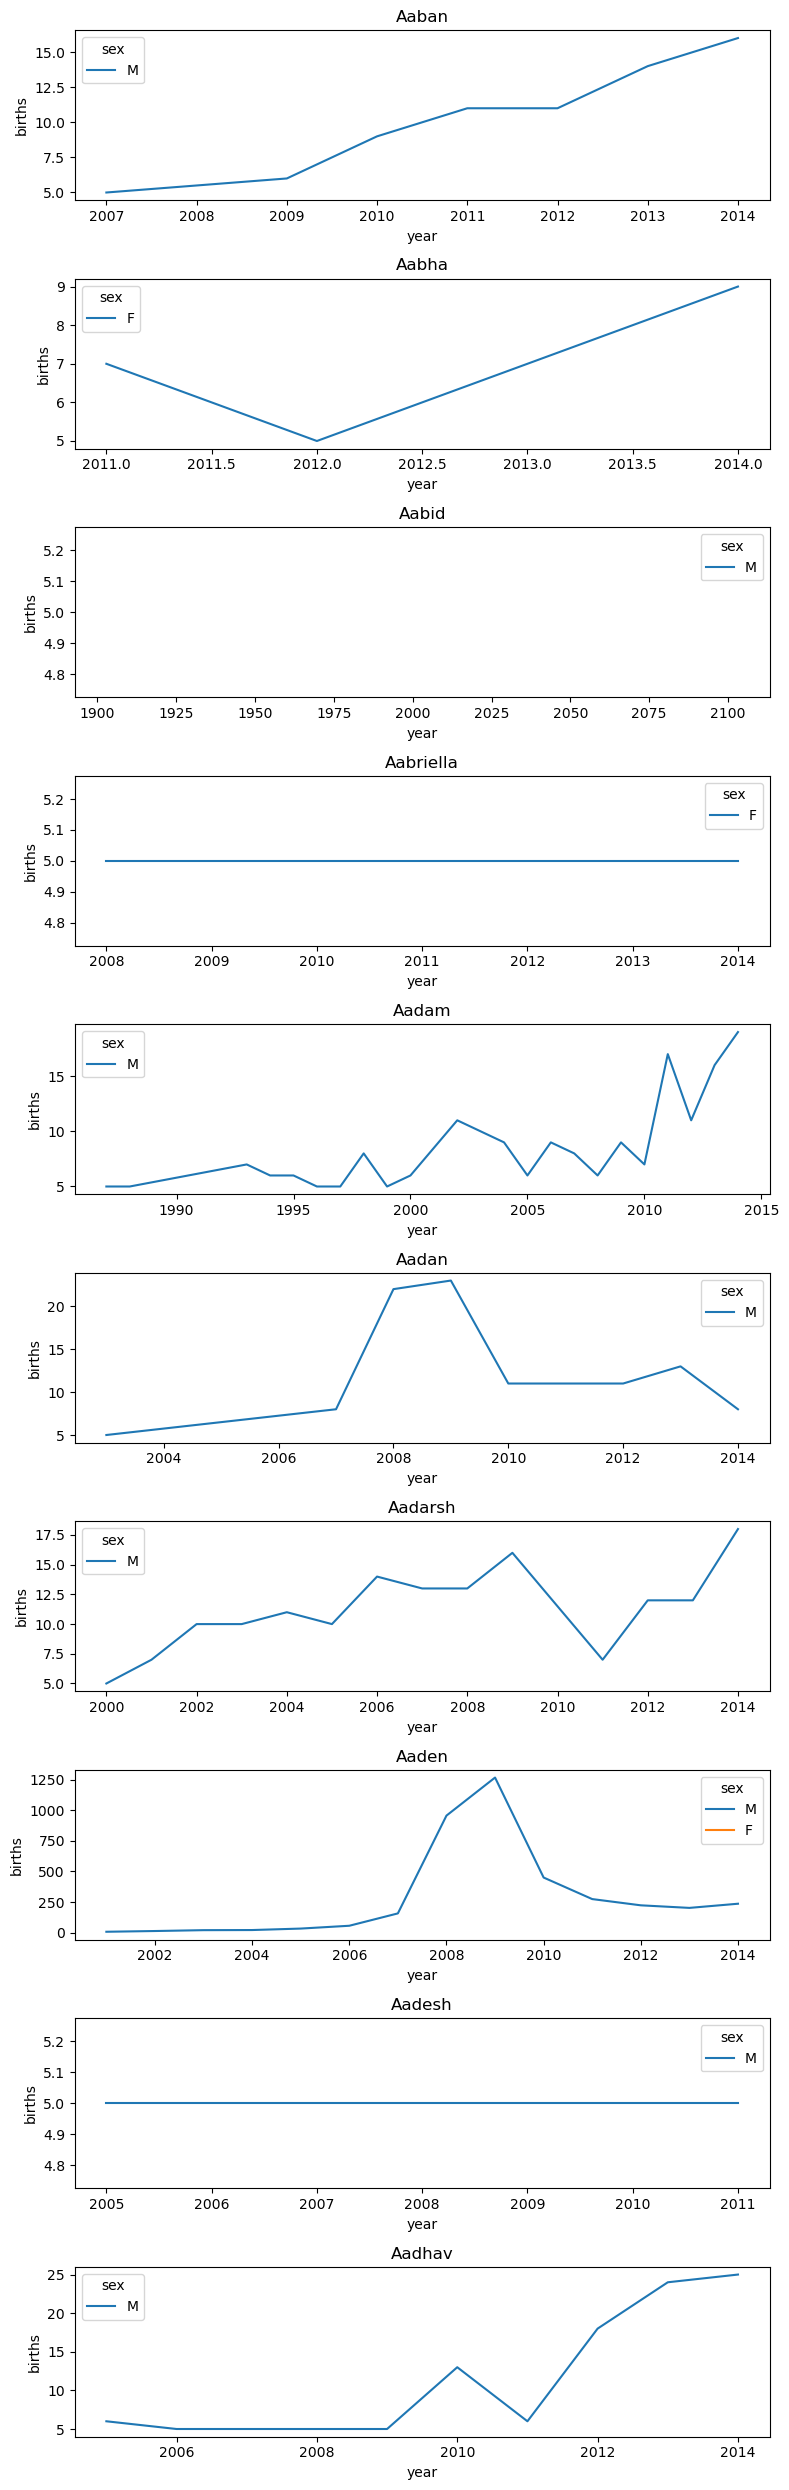

In [5]:
fig, axes = plt.subplots(10, 1, figsize=(8, 25))

for index, name in enumerate(top_names):
  name_df = final_df.loc[final_df['name'] == name, :]

  sns.lineplot(
    data=name_df,
    x='year',
    y='births',
    hue='sex',
    ax=axes[index]
  )

  axes[index].set_title(name)

plt.tight_layout()
plt.show()